<a href="https://colab.research.google.com/github/TerteryanTatev/Optimization-Methods/blob/main/Steepest-Descent-Gradient/steepest_descent_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from tabulate import tabulate

x1_sym, x2_sym, x3_sym = sp.symbols('x1 x2 x3')

f_sym = 0.5 * (5*x1_sym**2 - 2*x1_sym*x2_sym + 7*x2_sym**2 - 4*x2_sym*x3_sym + 7*x3_sym**2) - 6*x1_sym + 8*x2_sym - 2*x3_sym

x0 = [3.0, -2.0, -3.0]
eps = 1e-3

df_dx1 = sp.diff(f_sym, x1_sym)
df_dx2 = sp.diff(f_sym, x2_sym)
df_dx3 = sp.diff(f_sym, x3_sym)


f_func = sp.lambdify((x1_sym, x2_sym, x3_sym), f_sym, 'numpy')
grad_func = sp.lambdify((x1_sym, x2_sym, x3_sym), (df_dx1, df_dx2, df_dx3), 'numpy')

def steepest_descent_universal(x0, eps):
    x1, x2, x3 = x0[0], x0[1], x0[2]
    history = []
    k = 0

    alpha_sym = sp.symbols('alpha')

    while True:
        g1, g2, g3 = grad_func(x1, x2, x3)
        g_norm = np.sqrt(g1**2 + g2**2 + g3**2)
        fk = f_func(x1, x2, x3)

        history.append({
            'k': k, 'x1': x1, 'x2': x2, 'x3': x3, 'f': fk, 'g_norm': g_norm
        })

        if g_norm < eps or k > 1000:
            break

        g_alpha = f_sym.subs([
            (x1_sym, x1 - alpha_sym * g1),
            (x2_sym, x2 - alpha_sym * g2),
            (x3_sym, x3 - alpha_sym * g3)
        ])

        dg_dalpha = sp.diff(g_alpha, alpha_sym)
        alpha_sol = sp.solve(dg_dalpha, alpha_sym)

        alpha = float(alpha_sol[0])

        x1 = x1 - alpha * g1
        x2 = x2 - alpha * g2
        x3 = x3 - alpha * g3

        k += 1

    return history

results = steepest_descent_universal(x0, eps)



In [ ]:

print("="*70)
print(f" ՖՈՒՆԿՑԻԱ՝ f = {f_sym}")
print(f" ԱՎՏՈՄԱՏ ԱԾԱՆՑՅԱԼՆԵՐ՝")
print(f" df/dx1 = {df_dx1}\n df/dx2 = {df_dx2}\n df/dx3 = {df_dx3}")
print("="*70)

table_data = []
for r in results:
    x_str = f"({r['x1']:.4f}, {r['x2']:.4f}, {r['x3']:.4f})^T"
    table_data.append([r['k'], x_str, f"{r['f']:.4f}", f"{r['g_norm']:.4f}"])

headers = ["k", "x^k (Ընթացիկ կետ)", "f(x^k)", "||∇f(x^k)||"]
print(tabulate(table_data, headers=headers, tablefmt="fancy_grid"))


 ՖՈՒՆԿՑԻԱ՝ f = 2.5*x1**2 - 1.0*x1*x2 - 6*x1 + 3.5*x2**2 - 2.0*x2*x3 + 8*x2 + 3.5*x3**2 - 2*x3
 ԱՎՏՈՄԱՏ ԱԾԱՆՑՅԱԼՆԵՐ՝
 df/dx1 = 5.0*x1 - 1.0*x2 - 6
 df/dx2 = -1.0*x1 + 7.0*x2 - 2.0*x3 + 8
 df/dx3 = -2.0*x2 + 7.0*x3 - 2
╒═════╤══════════════════════════════╤══════════╤═══════════════╕
│   k │ x^k (Ընթացիկ կետ)            │   f(x^k) │   ||∇f(x^k)|| │
╞═════╪══════════════════════════════╪══════════╪═══════════════╡
│   0 │ (3.0000, -2.0000, -3.0000)^T │  34      │       22.1585 │
├─────┼──────────────────────────────┼──────────┼───────────────┤
│   1 │ (1.2193, -1.5143, 0.0758)^T  │  -5.743  │        4.5604 │
├─────┼──────────────────────────────┼──────────┼───────────────┤
│   2 │ (1.0310, -1.0502, -0.1064)^T │  -6.9583 │        0.6974 │
├─────┼──────────────────────────────┼──────────┼───────────────┤
│   3 │ (0.9972, -1.0223, -0.0002)^T │  -6.9983 │        0.1586 │
├─────┼──────────────────────────────┼──────────┼───────────────┤
│   4 │ (0.9962, -1.0035, -0.0055)^T │  -6.9999 │        

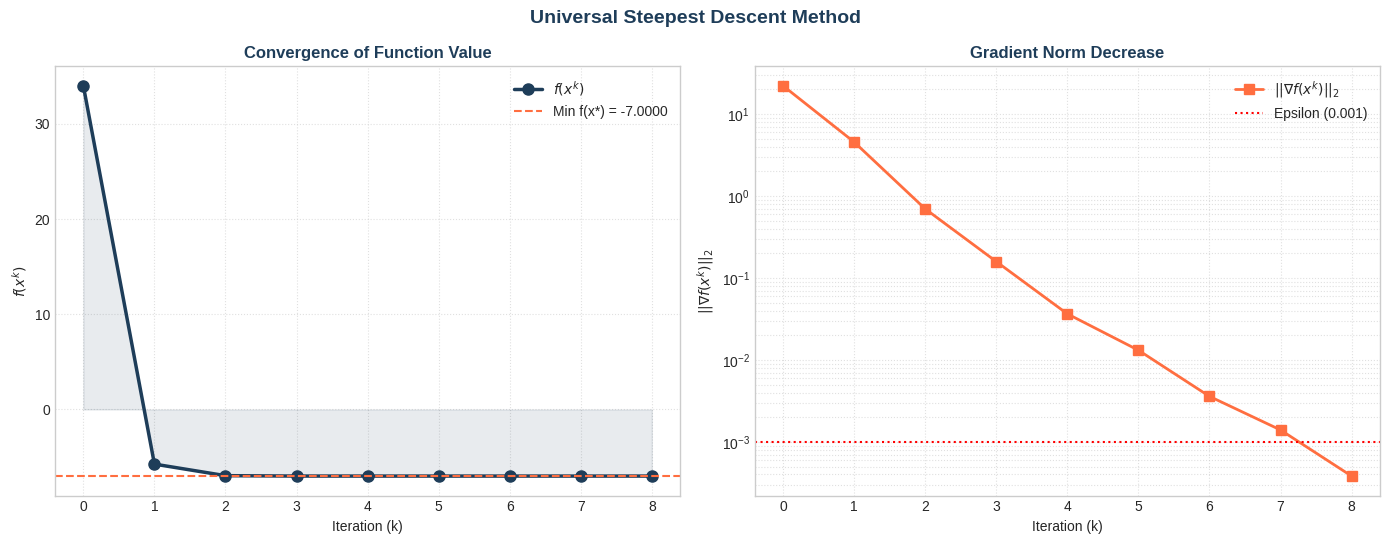

In [ ]:

# Գրաֆիկների բաժին
iterations = [r['k'] for r in results]
f_values = [r['f'] for r in results]
grad_norms = [r['g_norm'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

ax1.plot(iterations, f_values, 'o-', color='#1e3d59', linewidth=2.5, markersize=8, label='$f(x^k)$')
ax1.fill_between(iterations, f_values, color='#1e3d59', alpha=0.1)
ax1.axhline(y=f_values[-1], color='#ff6e40', linestyle='--', label=f'Min f(x*) = {f_values[-1]:.4f}')
ax1.set_title('Convergence of Function Value', fontsize=12, fontweight='bold', color='#1e3d59')
ax1.set_xlabel('Iteration (k)')
ax1.set_ylabel('$f(x^k)$')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.plot(iterations, grad_norms, 's-', color='#ff6e40', linewidth=2, markersize=7, label='$||\\nabla f(x^k)||_2$')
ax2.axhline(y=eps, color='red', linestyle=':', linewidth=1.5, label=f'Epsilon ({eps})')
ax2.set_title('Gradient Norm Decrease', fontsize=12, fontweight='bold', color='#1e3d59')
ax2.set_xlabel('Iteration (k)')
ax2.set_ylabel('$||\\nabla f(x^k)||_2$')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6, which="both")

plt.suptitle('Universal Steepest Descent Method', fontsize=14, fontweight='bold', color='#1e3d59', y=0.98)
plt.tight_layout()
plt.show()